In [1]:
from pathlib import Path
import shutil
import random
import json
import pandas as pd

SOURCE_ROOT = Path(r"C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\Trafik\Trafik")
LABELS_CSV = Path(r"C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\Trafik\labels.csv")
OUTPUT_ROOT = Path(r"C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\sign_classifier\dataset")

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SELECTED_CLASSES = {
    0: "hiz_siniri_20",
    1: "hiz_siniri_30",
    2: "hiz_siniri_40",
    3: "hiz_siniri_50",
    4: "yaya_gecidi",
    11: "dur",
    13: "girisi_olmayan_yol",
    21: "okul_gecidi",
    24: "tasit_giremez",
    25: "saga_donulmez",
    26: "sola_donulmez",
    48: "yol_calismasi",
    49: "isikli_isaret_cihazi",
    67: "dikkat",
    77: "yol_ver",
    81: "park_etmek_yasaktir",
    82: "duraklamak_park_yasaktir",
}

random.seed(SEED)

if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

for split in ["train", "val", "test"]:
    for class_name in SELECTED_CLASSES.values():
        (OUTPUT_ROOT / split / class_name).mkdir(parents=True, exist_ok=True)

class_map = {}

for new_id, (old_id, class_name) in enumerate(SELECTED_CLASSES.items()):
    src_dir = SOURCE_ROOT / str(old_id)

    if not src_dir.exists():
        print(f"Eksik klasör: {src_dir}")
        continue

    images = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
        images.extend(list(src_dir.glob(ext)))

    images = sorted(images)
    random.shuffle(images)

    n = len(images)
    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)

    split_files = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:],
    }

    for split, files in split_files.items():
        dst_dir = OUTPUT_ROOT / split / class_name

        for img_path in files:
            dst_path = dst_dir / img_path.name
            shutil.copy2(img_path, dst_path)

    class_map[new_id] = {
        "old_class_id": old_id,
        "class_name": class_name,
        "total": n,
        "train": len(split_files["train"]),
        "val": len(split_files["val"]),
        "test": len(split_files["test"]),
    }

    print(
        f"{old_id:02d} -> {class_name}: "
        f"total={n}, train={len(split_files['train'])}, "
        f"val={len(split_files['val'])}, test={len(split_files['test'])}"
    )

with open(OUTPUT_ROOT / "class_map.json", "w", encoding="utf-8") as f:
    json.dump(class_map, f, ensure_ascii=False, indent=2)

print("\nDataset hazırlandı:")
print(OUTPUT_ROOT)

00 -> hiz_siniri_20: total=125, train=87, val=18, test=20
01 -> hiz_siniri_30: total=166, train=116, val=24, test=26
02 -> hiz_siniri_40: total=126, train=88, val=18, test=20
03 -> hiz_siniri_50: total=167, train=116, val=25, test=26
04 -> yaya_gecidi: total=168, train=117, val=25, test=26
11 -> dur: total=507, train=354, val=76, test=77
13 -> girisi_olmayan_yol: total=245, train=171, val=36, test=38
21 -> okul_gecidi: total=590, train=413, val=88, test=89
24 -> tasit_giremez: total=364, train=254, val=54, test=56
25 -> saga_donulmez: total=548, train=383, val=82, test=83
26 -> sola_donulmez: total=516, train=361, val=77, test=78
48 -> yol_calismasi: total=126, train=88, val=18, test=20
49 -> isikli_isaret_cihazi: total=248, train=173, val=37, test=38
67 -> dikkat: total=126, train=88, val=18, test=20
77 -> yol_ver: total=126, train=88, val=18, test=20
81 -> park_etmek_yasaktir: total=126, train=88, val=18, test=20
82 -> duraklamak_park_yasaktir: total=126, train=88, val=18, test=20

D

Cihaz: cuda
Sınıf sayısı: 17
Sınıflar: ['dikkat', 'dur', 'duraklamak_park_yasaktir', 'girisi_olmayan_yol', 'hiz_siniri_20', 'hiz_siniri_30', 'hiz_siniri_40', 'hiz_siniri_50', 'isikli_isaret_cihazi', 'okul_gecidi', 'park_etmek_yasaktir', 'saga_donulmez', 'sola_donulmez', 'tasit_giremez', 'yaya_gecidi', 'yol_calismasi', 'yol_ver']
Train: 3073 Val: 650 Test: 677
Toplam parametre: 11185233
Eğitilen parametre: 10502161


C:\Users\hdgn5\AppData\Local\Temp\ipykernel_19816\538648236.py:113: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
C:\Users\hdgn5\AppData\Local\Temp\ipykernel_19816\538648236.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
C:\Users\hdgn5\AppData\Local\Temp\ipykernel_19816\538648236.py:157: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/30 | Train Loss: 0.8842 Acc: 0.8256 | Val Loss: 0.4189 Acc: 0.9708 | Best: 0.9708 | LR: 0.000100 | 29.3s
Epoch 02/30 | Train Loss: 0.4069 Acc: 0.9821 | Val Loss: 0.3737 Acc: 0.9908 | Best: 0.9908 | LR: 0.000100 | 28.0s
Epoch 03/30 | Train Loss: 0.3718 Acc: 0.9941 | Val Loss: 0.3426 Acc: 0.9985 | Best: 0.9985 | LR: 0.000100 | 28.5s
Epoch 04/30 | Train Loss: 0.3560 Acc: 0.9990 | Val Loss: 0.3401 Acc: 1.0000 | Best: 1.0000 | LR: 0.000100 | 28.6s
Epoch 05/30 | Train Loss: 0.3521 Acc: 0.9984 | Val Loss: 0.3368 Acc: 1.0000 | Best: 1.0000 | LR: 0.000100 | 29.0s
Epoch 06/30 | Train Loss: 0.3524 Acc: 0.9977 | Val Loss: 0.3371 Acc: 1.0000 | Best: 1.0000 | LR: 0.000100 | 27.9s
Epoch 07/30 | Train Loss: 0.3482 Acc: 0.9974 | Val Loss: 0.3324 Acc: 1.0000 | Best: 1.0000 | LR: 0.000100 | 29.2s
Epoch 08/30 | Train Loss: 0.3436 Acc: 0.9997 | Val Loss: 0.3318 Acc: 1.0000 | Best: 1.0000 | LR: 0.000050 | 30.2s
Epoch 09/30 | Train Loss: 0.3426 Acc: 0.9997 | Val Loss: 0.3303 Acc: 1.0000 | Best: 1.00

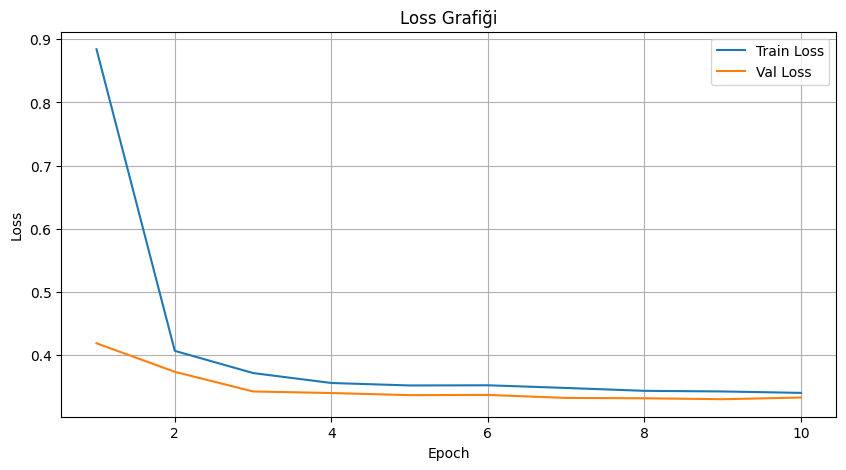

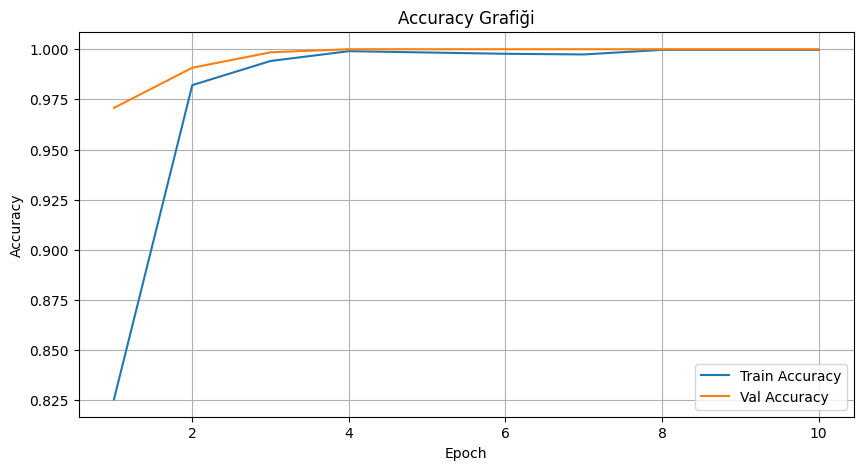

<Figure size 1600x1600 with 0 Axes>

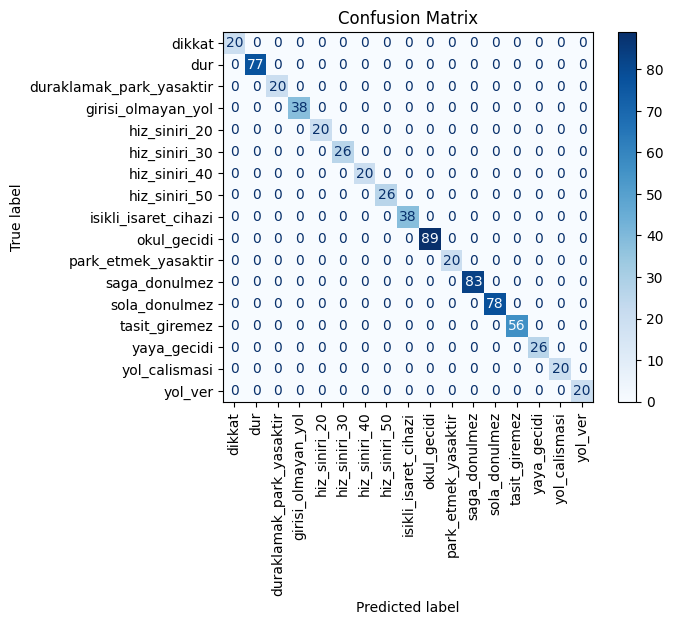

In [2]:
from pathlib import Path
import json
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

PROJECT_ROOT = Path(r"C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\sign_classifier")
DATA_ROOT = PROJECT_ROOT / "dataset"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-4
IMG_SIZE = 224
NUM_WORKERS = 0
SEED = 42
PATIENCE = 6

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Cihaz:", device)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.30),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.90, 1.10)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(DATA_ROOT / "train", transform=train_tfms)
val_ds = datasets.ImageFolder(DATA_ROOT / "val", transform=eval_tfms)
test_ds = datasets.ImageFolder(DATA_ROOT / "test", transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)

print("Sınıf sayısı:", num_classes)
print("Sınıflar:", class_names)
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(model.fc.in_features, num_classes)
)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Toplam parametre:", total_params)
print("Eğitilen parametre:", trainable_params)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
bad_epochs = 0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    model.train()
    train_loss = 0.0
    train_correct = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        train_loss += loss.item() * images.size(0)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_ds)
    train_acc = train_correct / len(train_ds)

    model.eval()
    val_loss = 0.0
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            val_loss += loss.item() * images.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_ds)
    val_acc = val_correct / len(val_ds)

    scheduler.step(val_acc)

    elapsed = time.time() - start
    current_lr = optimizer.param_groups[0]["lr"]

    improved = val_acc > best_acc

    if improved:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        bad_epochs = 0

        torch.save({
            "model_state_dict": best_model_wts,
            "class_names": class_names,
            "num_classes": num_classes,
            "img_size": IMG_SIZE,
            "model_name": "resnet18_partial_finetune",
        }, OUTPUT_DIR / "sign_classifier_resnet18_best.pt")
    else:
        bad_epochs += 1

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": current_lr,
        "time_sec": elapsed,
        "best_val_acc": best_acc,
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
        f"Best: {best_acc:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"{elapsed:.1f}s"
    )

    if bad_epochs >= PATIENCE:
        print(f"Early stopping aktif oldu. {PATIENCE} epoch iyileşme yok.")
        break

model.load_state_dict(best_model_wts)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

with open(OUTPUT_DIR / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

with open(OUTPUT_DIR / "classification_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(OUTPUT_DIR / "classification_report.csv")

print("\nEn iyi validation accuracy:", best_acc)
print("Test accuracy:", test_acc)
print("Model:", OUTPUT_DIR / "sign_classifier_resnet18_best.pt")
print("Class names:", OUTPUT_DIR / "class_names.json")

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Grafiği")
plt.legend()
plt.grid(True)
plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Grafiği")
plt.legend()
plt.grid(True)
plt.savefig(OUTPUT_DIR / "accuracy_curve.png", dpi=200, bbox_inches="tight")
plt.show()

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix")
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()